In [5]:
import simpy
import random
import numpy as np
import matplotlib.pyplot as plt

# Estilo para os gráficos ficarem com aparência acadêmica
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(100)
random.seed(100)

# ==========================================
# NÚCLEO DO SIMULADOR (FILAS E MÉTRICAS)
# ==========================================
class AmbienteAtendimento:
    def __init__(self, env, capacidade_servidores, taxa_atendimento_mu):
        self.env = env
        self.servidor = simpy.Resource(env, capacity=capacidade_servidores)
        self.mu = taxa_atendimento_mu
        
        # Variável de controle dinâmico para o Regime Markoviano
        self.lambda_vigente = 0.0 
        
        # Estruturas de armazenamento bruto
        self.registros_clientes = [] # Guarda tuplas: (chegada, inicio_serv, saida)
        self.historico_tamanho_fila = []
        self.historico_ocupacao = []

    def processar_cliente(self, tempo_chegada):
        with self.servidor.request() as req:
            yield req
            tempo_inicio = self.env.now
            
            # Tempo de serviço segue distribuição exponencial
            yield self.env.timeout(random.expovariate(self.mu))
            
            tempo_saida = self.env.now
            self.registros_clientes.append((tempo_chegada, tempo_inicio, tempo_saida))

def injetor_clientes_base(env, ambiente, limite_clientes=None):
    """Gera chegadas baseadas no lambda vigente do ambiente."""
    contador = 0
    while True:
        if limite_clientes and contador >= limite_clientes:
            break
            
        if ambiente.lambda_vigente > 0:
            intervalo = random.expovariate(ambiente.lambda_vigente)
            yield env.timeout(intervalo)
            env.process(ambiente.processar_cliente(env.now))
            contador += 1
        else:
            yield env.timeout(0.5) # Aguarda se a taxa for zero (estado inativo)

def observador_sistema(env, ambiente, taxa_amostragem=1.0):
    """Tira 'fotos' do sistema periodicamente para gerar os gráficos."""
    while True:
        ambiente.historico_tamanho_fila.append(len(ambiente.servidor.queue))
        ambiente.historico_ocupacao.append(ambiente.servidor.count / ambiente.servidor.capacity)
        yield env.timeout(taxa_amostragem)

def extrair_metricas_filas(ambiente):
    """Processa os dados brutos e retorna [L, Lq, W, Wq, Rho]"""
    if not ambiente.registros_clientes:
        return 0, 0, 0, 0, 0

    tempos = np.array(ambiente.registros_clientes)
    chegadas, inicios, saidas = tempos[:, 0], tempos[:, 1], tempos[:, 2]
    
    # Tempos de espera (W e Wq)
    Wq_array = inicios - chegadas
    W_array = saidas - chegadas
    Wq_medio = np.mean(Wq_array)
    W_medio = np.mean(W_array)
    
    # Quantidades (L e Lq) baseadas nas observações
    Lq_medio = np.mean(ambiente.historico_tamanho_fila)
    rho_medio = np.mean(ambiente.historico_ocupacao)
    L_medio = Lq_medio + (rho_medio * ambiente.servidor.capacity) # L = Lq + c*rho
    
    return L_medio, Lq_medio, W_medio, Wq_medio, rho_medio


--- REGIME POISSON: AVALIAÇÃO DE CARGA ---
λ=2.0 | Utilização: 19.4% | Espera Fila (Wq): 0.0272 | Tamanho Fila (Lq): 0.0565
λ=4.0 | Utilização: 41.3% | Espera Fila (Wq): 0.0659 | Tamanho Fila (Lq): 0.2700
λ=6.0 | Utilização: 57.2% | Espera Fila (Wq): 0.1429 | Tamanho Fila (Lq): 0.8475
λ=8.0 | Utilização: 79.2% | Espera Fila (Wq): 0.3282 | Tamanho Fila (Lq): 2.6015
λ=9.5 | Utilização: 94.5% | Espera Fila (Wq): 1.5678 | Tamanho Fila (Lq): 14.8235


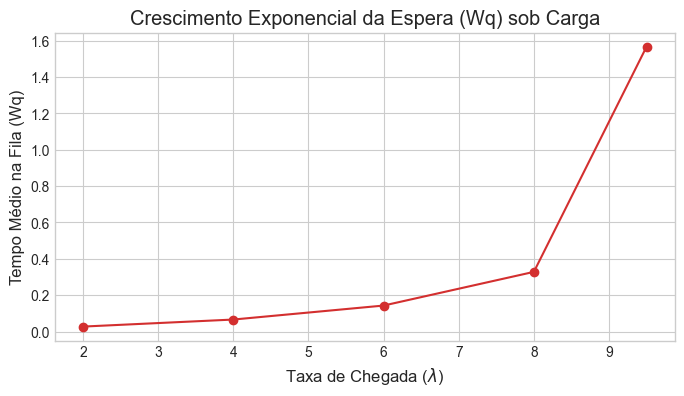

In [ ]:
# ==========================================
# 2. EXPERIMENTO A: REGIME POISSON (M/M/1 e M/M/c)
# ==========================================
def executar_analise_poisson():
    cenarios_lambda = [2.0, 4.0, 6.0, 8.0, 9.5]
    MU_FIXO = 10.0
    SERVIDORES = 1
    TEMPO_SIM = 2000
    
    resultados_Wq = []
    
    print("--- REGIME POISSON: AVALIAÇÃO DE CARGA ---")
    for taxa in cenarios_lambda:
        env = simpy.Environment()
        sistema = AmbienteAtendimento(env, SERVIDORES, MU_FIXO)
        sistema.lambda_vigente = taxa
        
        env.process(injetor_clientes_base(env, sistema))
        env.process(observador_sistema(env, sistema))
        env.run(until=TEMPO_SIM)
        
        L, Lq, W, Wq, rho = extrair_metricas_filas(sistema)
        resultados_Wq.append(Wq)
        print(f"λ={taxa} | Utilização: {rho*100:.1f}% | Espera Fila (Wq): {Wq:.4f} | Tamanho Fila (Lq): {Lq:.4f}")

    # Visualização
    plt.figure(figsize=(8, 4))
    plt.plot(cenarios_lambda, resultados_Wq, marker='o', linestyle='-', color='#d32f2f')
    plt.title('Crescimento Exponencial da Espera (Wq) sob Carga')
    plt.xlabel(r'Taxa de Chegada ($\lambda$)')
    plt.ylabel('Tempo Médio na Fila (Wq)')
    plt.show()

executar_analise_poisson()

Simulando tráfego com Burstiness (Rajadas)...

--- REGIME AUTOSSIMILAR ---
Parâmetro de Hurst Est.: H = 0.8635
Utilização (Rho): 99.1% | Tamanho Fila (Lq): 1765.17


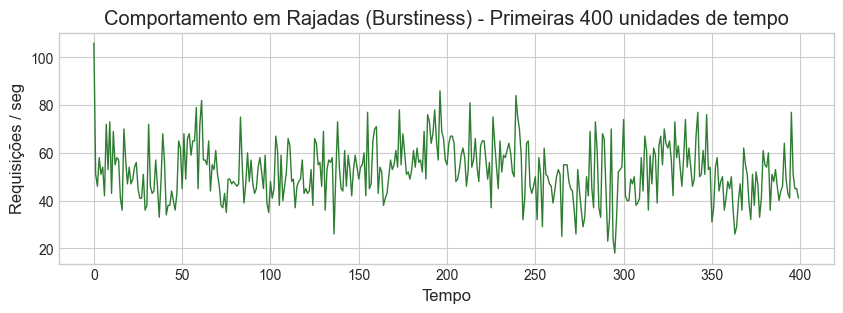

In [ ]:
# ==========================================
# EXPERIMENTO B: TRÁFEGO AUTOSSIMILAR E BURSTINESS
# ==========================================
def gerador_fractal_pareto(env, ambiente, alfa, taxa_rajada):
    """Implementa o tráfego em rajadas usando agregação de fontes de cauda pesada."""
    while True:
        # Alterna entre períodos ON (enviando pacotes) e OFF (ocioso)
        periodo_on = np.random.pareto(alfa) + 1
        periodo_off = np.random.pareto(alfa) + 1
        
        fim_on = env.now + periodo_on
        while env.now < fim_on:
            yield env.timeout(random.expovariate(taxa_rajada))
            env.process(ambiente.processar_cliente(env.now))
            
        yield env.timeout(periodo_off)

def calcular_hurst_r_s(serie_temporal):
    """Estimação do Parâmetro H pelo método de Agregação de Variância."""
    tamanhos = np.array([2, 4, 8, 16, 32, 64])
    vars_agregadas = []
    
    for m in tamanhos:
        # Agrupa os dados em janelas de tamanho 'm' e tira a variância das médias
        tamanho_valido = len(serie_temporal) - (len(serie_temporal) % m)
        blocos = np.array(serie_temporal[:tamanho_valido]).reshape(-1, m)
        medias_blocos = np.mean(blocos, axis=1)
        vars_agregadas.append(np.var(medias_blocos))
        
    x = np.log2(tamanhos)
    y = np.log2(vars_agregadas)
    
    # Regressão linear: coef[0] é o slope (beta)
    coefs = np.polyfit(x, y, 1)
    beta = coefs[0]
    
    # Relação matemática: Var(m) ~ m^(-beta). Logo: beta = 2 - 2H -> H = 1 - (beta/2)
    # Como a correlação é negativa, usamos valor absoluto para ajuste
    H = 1 + (beta / 2) 
    return H

def executar_analise_autossimilar():
    env = simpy.Environment()
    sistema = AmbienteAtendimento(env, capacidade_servidores=1, taxa_atendimento_mu=50.0)
    
    # Configurações do tráfego autossimilar
    QTD_FONTES = 20
    ALFA_PARETO = 1.3 # 1 < alfa < 2 garante cauda pesada
    TAXA_RAJADA = 5.0
    TEMPO_SIM = 5000
    
    # Inicia as fontes simultâneas
    for _ in range(QTD_FONTES):
        env.process(gerador_fractal_pareto(env, sistema, ALFA_PARETO, TAXA_RAJADA))
        
    env.process(observador_sistema(env, sistema, taxa_amostragem=1.0))
    print("Simulando tráfego com Burstiness (Rajadas)...")
    env.run(until=TEMPO_SIM)
    
    # Conta chegadas por unidade de tempo para a série temporal
    tempos_chegada = [t[0] for t in sistema.registros_clientes]
    bins = np.arange(0, TEMPO_SIM + 1, 1.0)
    serie_pacotes, _ = np.histogram(tempos_chegada, bins=bins)
    
    H_calc = calcular_hurst_r_s(serie_pacotes)
    L, Lq, W, Wq, rho = extrair_metricas_filas(sistema)
    
    print("\n--- REGIME AUTOSSIMILAR ---")
    print(f"Parâmetro de Hurst Est.: H = {H_calc:.4f}")
    print(f"Utilização (Rho): {rho*100:.1f}% | Tamanho Fila (Lq): {Lq:.2f}")
    
    plt.figure(figsize=(10, 3))
    plt.plot(serie_pacotes[:400], color='#2e7d32', linewidth=1)
    plt.title('Comportamento em Rajadas (Burstiness) - Primeiras 400 unidades de tempo')
    plt.xlabel('Tempo')
    plt.ylabel('Requisições / seg')
    plt.show()

executar_analise_autossimilar()

--- REGIME MARKOVIANO: DISTRIBUIÇÃO DE CARGA ---
Tempo no estado BAIXO: 36.5%
Tempo no estado MÉDIO: 46.0%
Tempo no estado ALTO:  17.5%

--- DISTRIBUIÇÃO TEÓRICA ESPERADA (Álgebra Linear) ---
Baixo: 36.4% | Médio: 45.5% | Alto: 18.2%


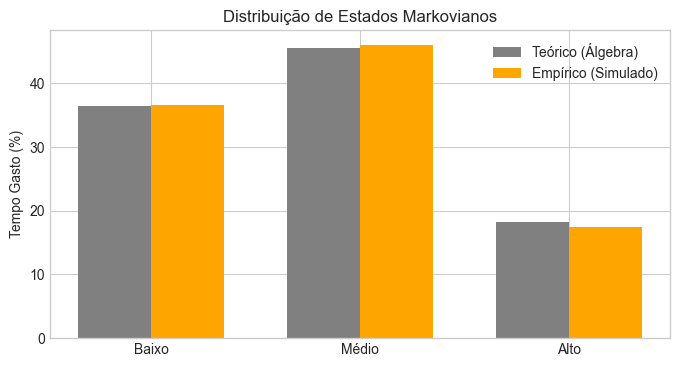

In [6]:
# ==========================================
# EXPERIMENTO C: REGIME MARKOVIANO E MODULAÇÃO
# ==========================================
def modulador_markoviano(env, ambiente, matriz_transicao, vetor_lambdas, tempo_permanencia):
    """Altera o estado do sistema baseado nas probabilidades da Matriz de Markov."""
    estado_atual = 0 # 0: Baixo, 1: Médio, 2: Alto
    historico_estados = []
    
    while True:
        # Atualiza o lambda global e registra o estado
        ambiente.lambda_vigente = vetor_lambdas[estado_atual]
        historico_estados.append(estado_atual)
        
        yield env.timeout(tempo_permanencia)
        
        # Sorteia o próximo estado
        estado_atual = np.random.choice([0, 1, 2], p=matriz_transicao[estado_atual])
        
        # Injeta uma referência do histórico no ambiente para a avaliação final
        ambiente.historico_estados_markov = historico_estados

def executar_analise_markov():
    env = simpy.Environment()
    sistema = AmbienteAtendimento(env, capacidade_servidores=2, taxa_atendimento_mu=10.0)
    
    # 1. Definições da Cadeia
    lambdas_estados = [5.0, 15.0, 25.0] # Baixo, Médio, Alto
    P = np.array([
        [0.7, 0.3, 0.0],
        [0.2, 0.6, 0.2],
        [0.1, 0.4, 0.5]
    ])
    
    # 2. Execução
    env.process(modulador_markoviano(env, sistema, P, lambdas_estados, tempo_permanencia=50))
    env.process(injetor_clientes_base(env, sistema))
    env.run(until=10000)
    
    # 3. Cálculo da Proporção Empírica
    estados = np.array(sistema.historico_estados_markov)
    p_baixo = np.sum(estados == 0) / len(estados)
    p_medio = np.sum(estados == 1) / len(estados)
    p_alto = np.sum(estados == 2) / len(estados)
    
    print("--- REGIME MARKOVIANO: DISTRIBUIÇÃO DE CARGA ---")
    print(f"Tempo no estado BAIXO: {p_baixo*100:.1f}%")
    print(f"Tempo no estado MÉDIO: {p_medio*100:.1f}%")
    print(f"Tempo no estado ALTO:  {p_alto*100:.1f}%")
    
    # 4. Cálculo Algébrico Teórico (pi * P = pi)
    autovalores, autovetores = np.linalg.eig(P.T)
    vetor_estacionario = autovetores[:, np.isclose(autovalores, 1)]
    vetor_estacionario = vetor_estacionario[:, 0].real
    pi_teorico = vetor_estacionario / vetor_estacionario.sum()
    
    print("\n--- DISTRIBUIÇÃO TEÓRICA ESPERADA (Álgebra Linear) ---")
    print(f"Baixo: {pi_teorico[0]*100:.1f}% | Médio: {pi_teorico[1]*100:.1f}% | Alto: {pi_teorico[2]*100:.1f}%")

    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(3)
    width = 0.35
    ax.bar(x - width/2, [pi_teorico[0]*100, pi_teorico[1]*100, pi_teorico[2]*100], width, label='Teórico (Álgebra)', color='gray')
    ax.bar(x + width/2, [p_baixo*100, p_medio*100, p_alto*100], width, label='Empírico (Simulado)', color='orange')
    ax.set_title('Distribuição de Estados Markovianos')
    ax.set_xticks(x)
    ax.set_xticklabels(['Baixo', 'Médio', 'Alto'])
    ax.set_ylabel('Tempo Gasto (%)')
    ax.legend()
    plt.show()
executar_analise_markov()


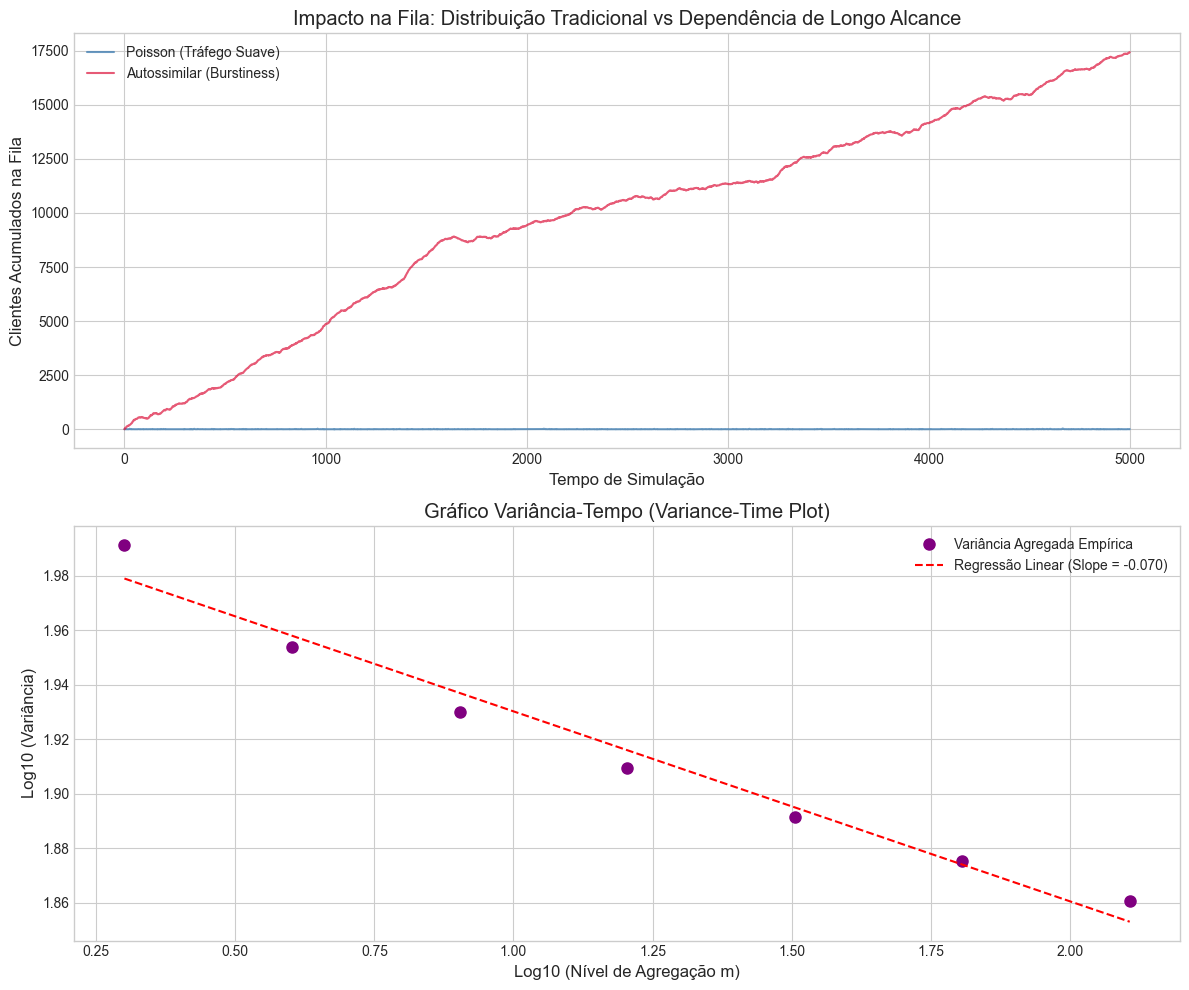

In [ ]:

# ==========================================
# COMPARAÇÃO FINAL: SUAVIDADE vs CAOS (BURSTINESS)
# ==========================================
def executar_comparacao_final():
    TEMPO_SIMULACAO = 5000
    CAPACIDADE_C = 2
    TAXA_MU = 10.0 # Capacidade total = 20
    
    # ----------------------------------------
    # 1. Rodando o concorrente A (Poisson Suave)
    # ----------------------------------------
    env_poisson = simpy.Environment()
    sis_poisson = AmbienteAtendimento(env_poisson, CAPACIDADE_C, TAXA_MU)
    sis_poisson.lambda_vigente = 15.0 # Carga de 75%
    
    env_poisson.process(injetor_clientes_base(env_poisson, sis_poisson))
    env_poisson.process(observador_sistema(env_poisson, sis_poisson, taxa_amostragem=1.0))
    env_poisson.run(until=TEMPO_SIMULACAO)

    # ----------------------------------------
    # 2. Rodando o concorrente B (Autossimilar em Rajadas)
    # ----------------------------------------
    env_auto = simpy.Environment()
    sis_auto = AmbienteAtendimento(env_auto, CAPACIDADE_C, TAXA_MU)
    
    # Vamos usar 15 fontes agressivas
    for _ in range(15):
        env_auto.process(gerador_fractal_pareto(env_auto, sis_auto, alfa=1.2, taxa_rajada=3.0))
        
    env_auto.process(observador_sistema(env_auto, sis_auto, taxa_amostragem=1.0))
    env_auto.run(until=TEMPO_SIMULACAO)

    # ----------------------------------------
    # 3. Matemática para o Gráfico de Variância-Tempo
    # ----------------------------------------
    # Extraindo a série temporal de chegadas
    tempos_chegada_auto = [t[0] for t in sis_auto.registros_clientes]
    bins = np.arange(0, TEMPO_SIMULACAO + 1, 1.0)
    contagem_pacotes, _ = np.histogram(tempos_chegada_auto, bins=bins)
    
    # Reconstruindo a agregação para o plot
    tamanhos_m = np.array([2, 4, 8, 16, 32, 64, 128])
    vars_agregadas = []
    
    for m in tamanhos_m:
        tamanho_valido = len(contagem_pacotes) - (len(contagem_pacotes) % m)
        blocos = np.array(contagem_pacotes[:tamanho_valido]).reshape(-1, m)
        medias = np.mean(blocos, axis=1)
        vars_agregadas.append(np.var(medias))
        
    log_m = np.log10(tamanhos_m)
    log_var = np.log10(vars_agregadas)
    
    # Calculando a reta de regressão
    coefs = np.polyfit(log_m, log_var, 1)
    slope = coefs[0]
    intercept = coefs[1]
    reta_regressao = (slope * log_m) + intercept
    
    # ----------------------------------------
    # 4. Geração dos Gráficos Lado a Lado
    # ----------------------------------------
    fig, axs = plt.subplots(2, 1, figsize=(12, 10))

    # Gráfico A: A prova visual do Burstiness
    tempo_x = np.arange(TEMPO_SIMULACAO)
    axs[0].plot(tempo_x, sis_poisson.historico_tamanho_fila[:TEMPO_SIMULACAO], 
                label='Poisson (Tráfego Suave)', alpha=0.8, color='steelblue')
    axs[0].plot(tempo_x, sis_auto.historico_tamanho_fila[:TEMPO_SIMULACAO], 
                label='Autossimilar (Burstiness)', alpha=0.7, color='crimson')
    axs[0].set_title('Impacto na Fila: Distribuição Tradicional vs Dependência de Longo Alcance')
    axs[0].set_ylabel('Clientes Acumulados na Fila')
    axs[0].set_xlabel('Tempo de Simulação')
    axs[0].legend()

    # Gráfico B: A prova matemática do Hurst (Variance-Time Plot)
    axs[1].plot(log_m, log_var, 'o', color='purple', label='Variância Agregada Empírica', markersize=8)
    axs[1].plot(log_m, reta_regressao, 'r--', label=f'Regressão Linear (Slope = {slope:.3f})')
    axs[1].set_title('Gráfico Variância-Tempo (Variance-Time Plot)')
    axs[1].set_ylabel('Log10 (Variância)')
    axs[1].set_xlabel('Log10 (Nível de Agregação m)')
    axs[1].legend()

    plt.tight_layout()
    plt.show()

# Dispara a comparação final
executar_comparacao_final()